# Training strategy comparison

Comparison of baseline, adaptive weighting, adaptive weighting with MLP heads, Group DRO, and separate-task training for RoBERTa full fine-tuning and Qwen LoRA.

The primary comparison uses seeds 2026–2028, which are available for every strategy. Group DRO and separate-task training additionally have seeds 2029–2030; those are analysed separately.

$$score = \frac{\min(F1_{sent,AU},F1_{sent,UK}) + \min(F1_{sarc,AU},F1_{sarc,UK})}{2}.$$

In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "training_summary" / "runs").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate training_summary/runs")

RUN_ROOT = find_repo_root() / "training_summary" / "runs"
COMMON_SEEDS = (2026, 2027, 2028)
EXTENDED_SEEDS = (2026, 2027, 2028, 2029, 2030)

RUNS = {
    "RoBERTa · Baseline": ("R1", "roberta_multitask", "RoBERTa", "Baseline"),
    "RoBERTa · Adaptive": ("R2", "roberta_adaptive_minvariety", "RoBERTa", "Adaptive"),
    "RoBERTa · Adaptive MLP": ("R3", "roberta_adaptive_minvariety_mlp", "RoBERTa", "Adaptive MLP"),
    "RoBERTa · Group DRO": ("R4", "roberta_group_dro", "RoBERTa", "Group DRO"),
    "RoBERTa · Separate tasks": ("R5", "roberta_separate_tasks", "RoBERTa", "Separate tasks"),
    "Qwen · Baseline": ("Q1", "qwen_embedding_0.6b_multitask_lora", "Qwen", "Baseline"),
    "Qwen · Adaptive": ("Q2", "qwen_embedding_0.6b_lora_adaptive_minvariety", "Qwen", "Adaptive"),
    "Qwen · Adaptive MLP": ("Q3", "qwen_embedding_0.6b_lora_adaptive_minvariety_mlp", "Qwen", "Adaptive MLP"),
    "Qwen · Group DRO": ("Q4", "qwen_embedding_0.6b_lora_group_dro", "Qwen", "Group DRO"),
    "Qwen · Separate tasks": ("Q5", "qwen_embedding_0.6b_lora_separate_tasks", "Qwen", "Separate tasks"),
}
STRATEGIES = ("Baseline", "Adaptive", "Adaptive MLP", "Group DRO", "Separate tasks")
MODELS = ("RoBERTa", "Qwen")
COLORS = {"Baseline": "#4C78A8", "Adaptive": "#E45756",
          "Adaptive MLP": "#72B7B2", "Group DRO": "#F2CF5B",
          "Separate tasks": "#B279A2"}

SUBTASKS = {
    "Sentiment AU": "en_AU_sentiment_macro_f1",
    "Sentiment UK": "en_UK_sentiment_macro_f1",
    "Sarcasm AU": "en_AU_sarcasm_macro_f1",
    "Sarcasm UK": "en_UK_sarcasm_macro_f1",
}

def benchmark_score(frame):
    sentiment = frame[["en_AU_sentiment_macro_f1", "en_UK_sentiment_macro_f1"]].min(axis=1)
    sarcasm = frame[["en_AU_sarcasm_macro_f1", "en_UK_sarcasm_macro_f1"]].min(axis=1)
    return (sentiment + sarcasm) / 2

frames = []
for run, (run_id, directory, model, strategy) in RUNS.items():
    path = RUN_ROOT / directory / "all_results.csv"
    if not path.is_file():
        raise FileNotFoundError(path)
    frame = pd.read_csv(path)
    frame.columns = [column.removeprefix("test_") for column in frame.columns]
    frame["split_seed"] = frame.split_seed.astype(int)
    frame["run"], frame["id"] = run, run_id
    frame["model"], frame["strategy"] = model, strategy
    frame["benchmark_score"] = benchmark_score(frame)
    frames.append(frame)

results = pd.concat(frames, ignore_index=True)
common = results[results.split_seed.isin(COMMON_SEEDS)].copy()
coverage = results.groupby(["id", "run"], sort=False).split_seed.agg(["count", "min", "max"])
display(coverage.rename(columns={"count": "n_seeds", "min": "first_seed", "max": "last_seed"}))

,,n_seeds,first_seed,last_seed
id,run,,,
R1,RoBERTa · Baseline,3,2026,2028
R2,RoBERTa · Adaptive,3,2026,2028
R3,RoBERTa · Adaptive MLP,3,2026,2028
R4,RoBERTa · Group DRO,5,2026,2030
R5,RoBERTa · Separate tasks,5,2026,2030
Q1,Qwen · Baseline,3,2026,2028
Q2,Qwen · Adaptive,3,2026,2028
Q3,Qwen · Adaptive MLP,3,2026,2028
Q4,Qwen · Group DRO,5,2026,2030


### Comparability

- Main comparisons use the same three splits.
- All runs use five epochs, effective batch size 16, maximum length 256, dropout 0.1, weight decay 0.01, and warmup ratio 0.1.
- RoBERTa is fully fine-tuned at 2e-5; Qwen uses LoRA at 2e-4.
- Strategies intentionally differ in objective, head, checkpoint selection, or backbone sharing.
- Test data is evaluated only after validation-based checkpoint selection.

## Common-seed summary and benchmark score

,Backbone,Strategy,Sentiment AU,Sentiment UK,Sarcasm AU,Sarcasm UK,Score
ID,,,,,,,
R1,RoBERTa,Baseline,0.9132 ± 0.0094,0.9497 ± 0.0067,0.7670 ± 0.0195,0.6445 ± 0.0100,0.7789 ± 0.0090
R2,RoBERTa,Adaptive,0.9152 ± 0.0103,0.9445 ± 0.0030,0.7362 ± 0.0238,0.6508 ± 0.0149,0.7830 ± 0.0032
R3,RoBERTa,Adaptive MLP,0.9090 ± 0.0016,0.9410 ± 0.0055,0.7647 ± 0.0249,0.6809 ± 0.0175,0.7949 ± 0.0095
R4,RoBERTa,Group DRO,0.9135 ± 0.0072,0.9480 ± 0.0026,0.7468 ± 0.0180,0.6721 ± 0.0191,0.7928 ± 0.0114
R5,RoBERTa,Separate tasks,0.9133 ± 0.0025,0.9488 ± 0.0076,0.7344 ± 0.0085,0.6892 ± 0.0146,0.8012 ± 0.0079
Q1,Qwen,Baseline,0.9206 ± 0.0069,0.9497 ± 0.0040,0.7774 ± 0.0129,0.6699 ± 0.0441,0.7953 ± 0.0255
Q2,Qwen,Adaptive,0.9195 ± 0.0031,0.9567 ± 0.0104,0.7543 ± 0.0138,0.6874 ± 0.0386,0.8034 ± 0.0189
Q3,Qwen,Adaptive MLP,0.9133 ± 0.0025,0.9575 ± 0.0061,0.7339 ± 0.0341,0.6930 ± 0.0302,0.8031 ± 0.0159
Q4,Qwen,Group DRO,0.9231 ± 0.0032,0.9489 ± 0.0040,0.7426 ± 0.0241,0.7016 ± 0.0165,0.8123 ± 0.0094


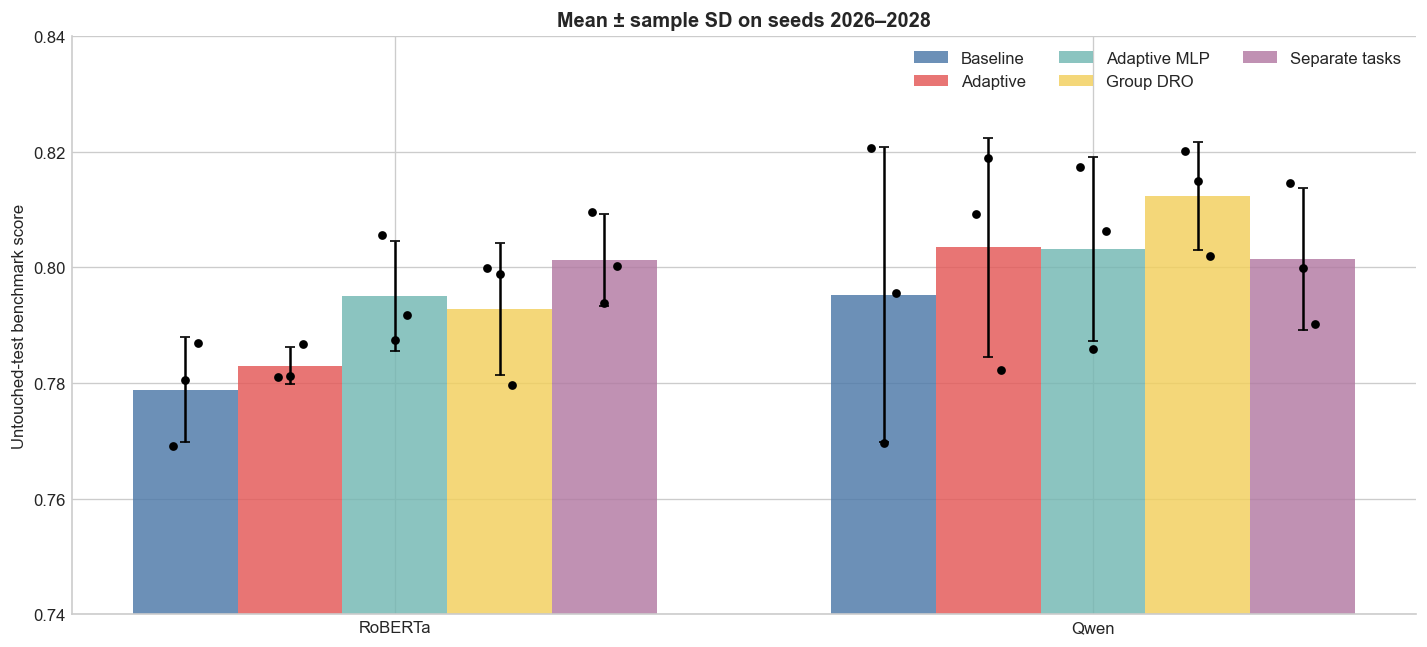

In [29]:
rows = []
for run, part in common.groupby("run", sort=False):
    run_id, _, model, strategy = RUNS[run]
    row = {"ID": run_id, "Backbone": model, "Strategy": strategy}
    for label, metric in SUBTASKS.items():
        row[label] = f"{part[metric].mean():.4f} ± {part[metric].std():.4f}"
    row["Score"] = f"{part.benchmark_score.mean():.4f} ± {part.benchmark_score.std():.4f}"
    rows.append(row)
display(pd.DataFrame(rows).set_index("ID"))

fig, ax = plt.subplots(figsize=(12, 5.5))
x, width = np.arange(len(MODELS)), 0.15
for offset, strategy in zip(np.linspace(-2 * width, 2 * width, len(STRATEGIES)), STRATEGIES):
    means, stds = [], []
    for model in MODELS:
        values = common[(common.model == model) & (common.strategy == strategy)].benchmark_score
        means.append(values.mean()); stds.append(values.std())
    positions = x + offset
    ax.bar(positions, means, width, yerr=stds, capsize=3,
           color=COLORS[strategy], alpha=0.82, label=strategy)
    for index, model in enumerate(MODELS):
        values = common[(common.model == model) & (common.strategy == strategy)].benchmark_score.to_numpy()
        ax.scatter(np.full(len(values), positions[index]) + np.linspace(-0.018, 0.018, len(values)),
                   values, color="black", s=18, zorder=3)
ax.set_xticks(x, MODELS); ax.set_ylim(0.74, 0.84)
ax.set_ylabel("Untouched-test benchmark score")
ax.set_title("Mean ± sample SD on seeds 2026–2028")
ax.legend(frameon=False, ncol=3)
fig.tight_layout(); plt.show()

## Four score components

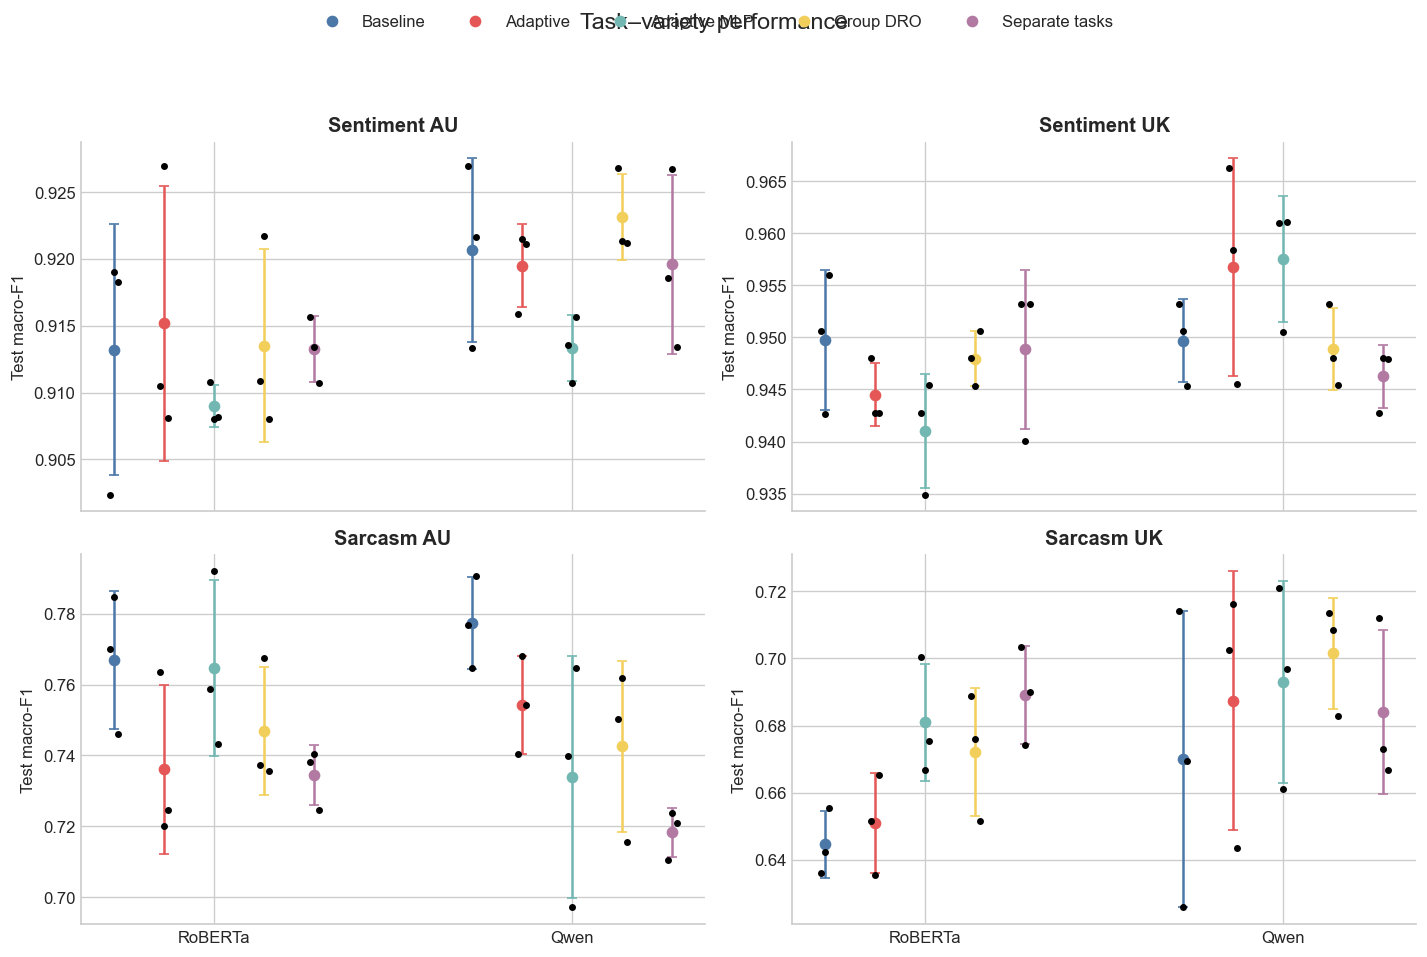

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
x = np.arange(len(MODELS))
for ax, (label, metric) in zip(axes.flat, SUBTASKS.items()):
    for offset, strategy in zip(np.linspace(-0.28, 0.28, len(STRATEGIES)), STRATEGIES):
        for index, model in enumerate(MODELS):
            values = common[(common.model == model) & (common.strategy == strategy)][metric]
            position = x[index] + offset
            ax.errorbar(position, values.mean(), yerr=values.std(), fmt="o", capsize=3,
                        color=COLORS[strategy], markersize=6)
            ax.scatter(np.full(len(values), position) + np.linspace(-0.012, 0.012, len(values)),
                       values, color="black", s=10, zorder=3)
    ax.set_title(label); ax.set_xticks(x, MODELS); ax.set_ylabel("Test macro-F1")
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=COLORS[s], label=s)
           for s in STRATEGIES]
fig.legend(handles=handles, loc="upper center", ncol=5, frameon=False)
fig.suptitle("Task–variety performance", y=0.99, fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

## Paired change from baseline

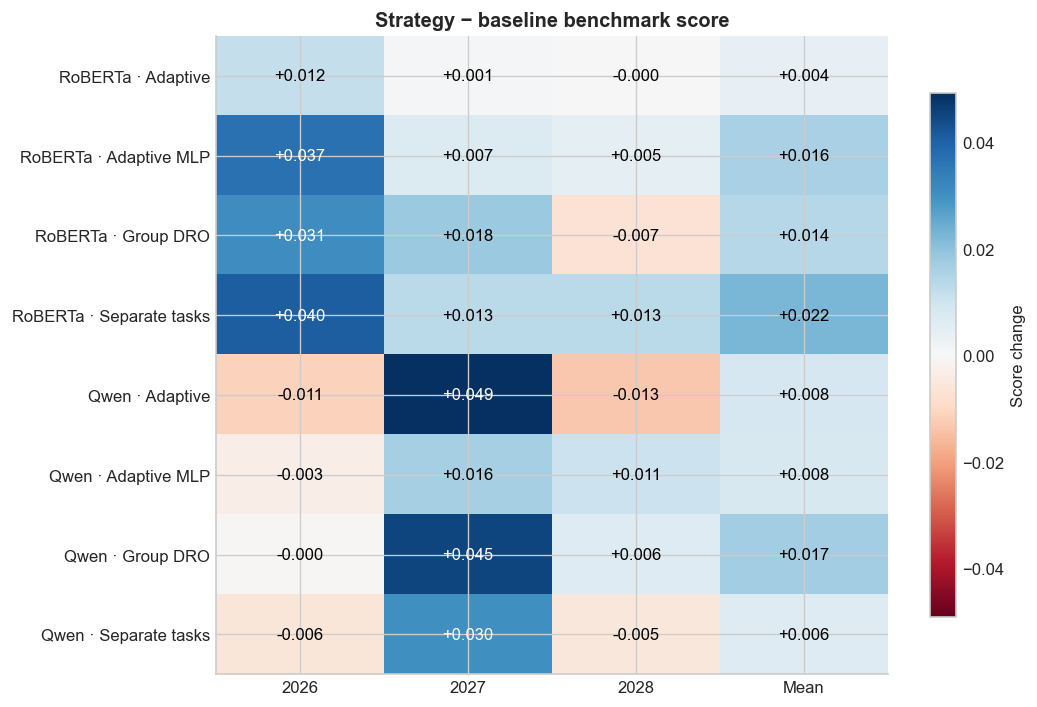

In [31]:
delta_rows = []
for model in MODELS:
    baseline = common[(common.model == model) & (common.strategy == "Baseline")].set_index("split_seed")
    for strategy in STRATEGIES[1:]:
        candidate = common[(common.model == model) & (common.strategy == strategy)].set_index("split_seed")
        delta = candidate.benchmark_score - baseline.benchmark_score
        delta_rows.append({"comparison": f"{model} · {strategy}",
                           **{str(seed): delta.loc[seed] for seed in COMMON_SEEDS},
                           "Mean": delta.mean()})
deltas = pd.DataFrame(delta_rows).set_index("comparison")
fig, ax = plt.subplots(figsize=(9, 6))
limit = np.abs(deltas.to_numpy()).max()
image = ax.imshow(deltas, cmap="RdBu", vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(len(deltas.columns)), deltas.columns)
ax.set_yticks(range(len(deltas.index)), deltas.index)
ax.set_title("Strategy − baseline benchmark score")
for row in range(deltas.shape[0]):
    for column in range(deltas.shape[1]):
        value = deltas.iloc[row, column]
        ax.text(column, row, f"{value:+.3f}", ha="center", va="center",
                color="white" if abs(value) > limit * 0.55 else "black")
fig.colorbar(image, ax=ax, label="Score change", shrink=0.82)
fig.tight_layout(); plt.show()

## Five-seed stability of Group DRO and separate-task training

This is supplementary because the other strategies do not yet contain seeds 2029–2030.

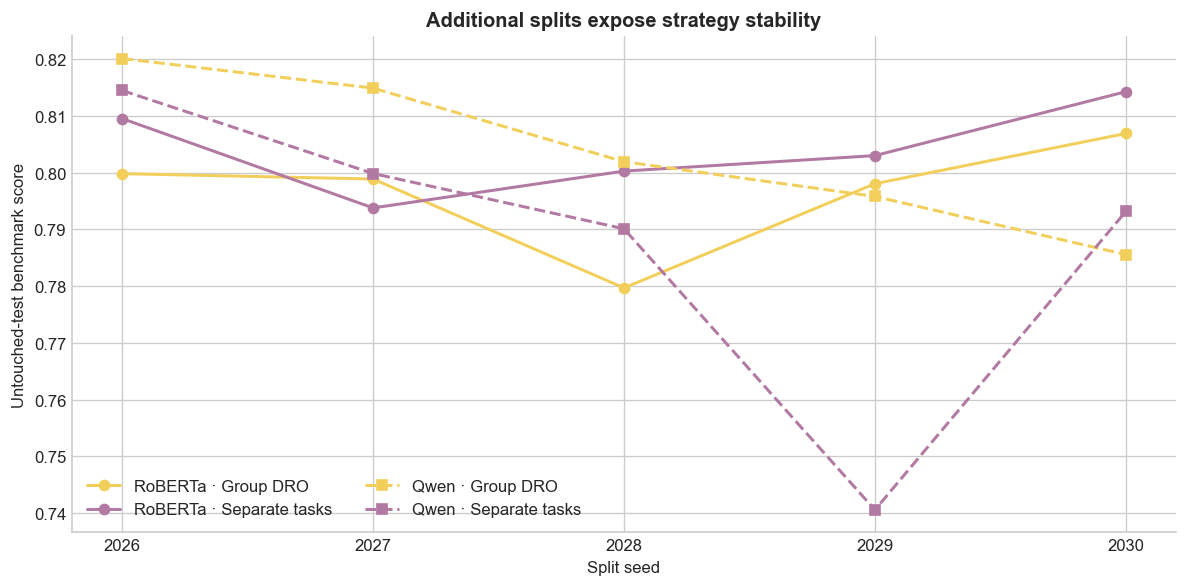

,,mean,std,min,max
model,strategy,,,,
RoBERTa,Separate tasks,0.8042,0.0080,0.7938,0.8143
Qwen,Group DRO,0.8037,0.0141,0.7856,0.8201
RoBERTa,Group DRO,0.7967,0.0101,0.7797,0.8069
Qwen,Separate tasks,0.7876,0.0280,0.7405,0.8145


In [32]:
extended = results[results.strategy.isin(["Group DRO", "Separate tasks"])
                   & results.split_seed.isin(EXTENDED_SEEDS)].copy()
fig, ax = plt.subplots(figsize=(10, 5))
for run, part in extended.groupby("run", sort=False):
    part = part.sort_values("split_seed")
    model, strategy = part.model.iloc[0], part.strategy.iloc[0]
    ax.plot(part.split_seed.astype(str), part.benchmark_score,
            marker="o" if model == "RoBERTa" else "s",
            linestyle="-" if model == "RoBERTa" else "--",
            color=COLORS[strategy], linewidth=1.8, label=run)
ax.set_xlabel("Split seed"); ax.set_ylabel("Untouched-test benchmark score")
ax.set_title("Additional splits expose strategy stability")
ax.legend(frameon=False, ncol=2); fig.tight_layout(); plt.show()

extended_summary = (extended.groupby(["model", "strategy"], sort=False).benchmark_score
                    .agg(["mean", "std", "min", "max"]).sort_values("mean", ascending=False))
display(extended_summary.style.format("{:.4f}"))

## Concise findings

In [33]:
ranked = common.groupby("run").benchmark_score.agg(["mean", "std"]).sort_values("mean", ascending=False)
def mean_score(model, strategy):
    return common[(common.model == model) & (common.strategy == strategy)].benchmark_score.mean()

best_run = ranked.index[0]
qwen_group_gain = mean_score("Qwen", "Group DRO") - mean_score("Qwen", "Baseline")
roberta_separate_gain = mean_score("RoBERTa", "Separate tasks") - mean_score("RoBERTa", "Baseline")
qwen_separate = extended[(extended.model == "Qwen") & (extended.strategy == "Separate tasks")].benchmark_score

display(Markdown(f'''\
- Best common-seed mean: **{best_run}**, {ranked.iloc[0]['mean']:.4f} ± {ranked.iloc[0]['std']:.4f}.
- Qwen Group DRO improves on the Qwen baseline by {qwen_group_gain:+.4f}.
- Separate-task RoBERTa improves on its baseline by {roberta_separate_gain:+.4f} and is the strongest RoBERTa strategy.
- Group DRO raises en_UK sarcasm for both backbones; this is the recurring score bottleneck.
- Separate-task Qwen is unstable over five splits: mean {qwen_separate.mean():.4f}, SD {qwen_separate.std():.4f}, minimum {qwen_separate.min():.4f}.
- Sentiment remains easier than sarcasm; tuning should prioritise robust sarcasm performance without sacrificing en_AU sentiment.
'''))

- Best common-seed mean: **Qwen · Group DRO**, 0.8123 ± 0.0094.
- Qwen Group DRO improves on the Qwen baseline by +0.0171.
- Separate-task RoBERTa improves on its baseline by +0.0224 and is the strongest RoBERTa strategy.
- Group DRO raises en_UK sarcasm for both backbones; this is the recurring score bottleneck.
- Separate-task Qwen is unstable over five splits: mean 0.7876, SD 0.0280, minimum 0.7405.
- Sentiment remains easier than sarcasm; tuning should prioritise robust sarcasm performance without sacrificing en_AU sentiment.
